### Dataset - https://www.kaggle.com/datasets/rakeshdasdata/rakesh-emotion-detection-fer

### 1. Obtain the Data : Emotion Detection Dataset

In [2]:
import os
import shutil
import pathlib

# Define paths
original_dir = pathlib.Path("DatasetEmotionDetection/train")  # Adjust the path as needed
new_base_dir = pathlib.Path("DatasetEmotionDetection_subset")

# Function to create subsets for training, validation, and testing
def make_subset(subset_name, split_ratio):
    """
    Creates subsets for training, validation, and testing dynamically.
    Args:
        subset_name: Name of the subset (train/validation/test).
        split_ratio: Tuple of split ratios for train, validation, and test (e.g., (0.7, 0.15, 0.15)).
    """
    for category in os.listdir(original_dir):  # Assuming the subfolders are the emotion labels
        category_dir = original_dir / category
        filenames = os.listdir(category_dir)
        
        # Split filenames based on split ratios
        total_files = len(filenames)
        train_end = int(split_ratio[0] * total_files)
        val_end = train_end + int(split_ratio[1] * total_files)
        
        # Define ranges for subsets
        subsets = {
            "train": filenames[:train_end],
            "validation": filenames[train_end:val_end],
            "test": filenames[val_end:]
        }
        
        # Copy files to their respective directories
        subset_filenames = subsets.get(subset_name, [])
        dest_dir = new_base_dir / subset_name / category
        os.makedirs(dest_dir, exist_ok=True)  # Create directories if they don't exist
        for fname in subset_filenames:
            shutil.copyfile(src=category_dir / fname, dst=dest_dir / fname)

# Define split ratios: (70% train, 15% validation, 15% test)
split_ratios = (0.7, 0.15, 0.15)

# Create subsets
make_subset("train", split_ratios)
make_subset("validation", split_ratios)
make_subset("test", split_ratios)

print("Data subsets created successfully!")


Data subsets created successfully!


### 2. EDA: Explore the data with relevant graphs, statistics and insights 

Training set distribution: {'angry': 2796, 'disgusted': 305, 'fearful': 2867, 'happy': 5050, 'neutral': 3475, 'sad': 3381, 'surprised': 2219}
Validation set distribution: {'angry': 599, 'disgusted': 65, 'fearful': 614, 'happy': 1082, 'neutral': 744, 'sad': 724, 'surprised': 475}
Test set distribution: {'angry': 600, 'disgusted': 66, 'fearful': 616, 'happy': 1083, 'neutral': 746, 'sad': 725, 'surprised': 477}


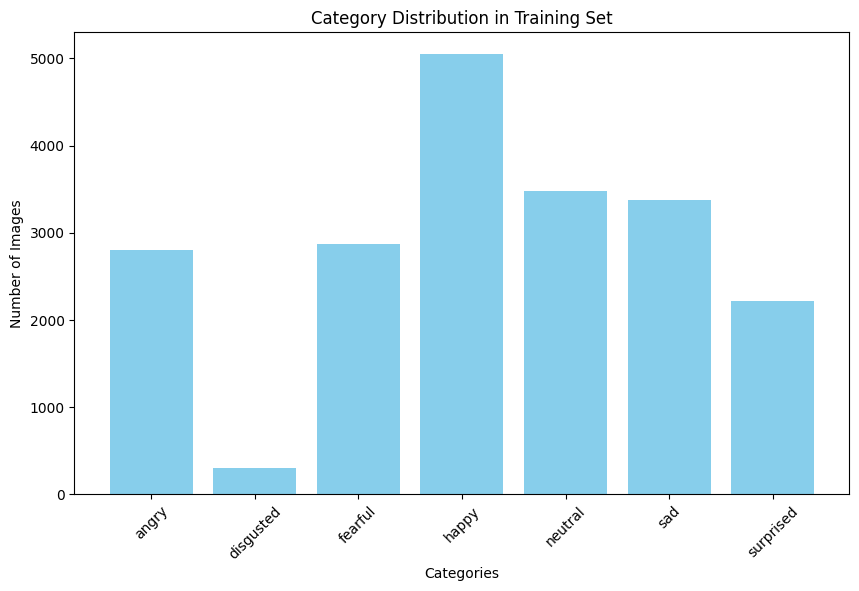

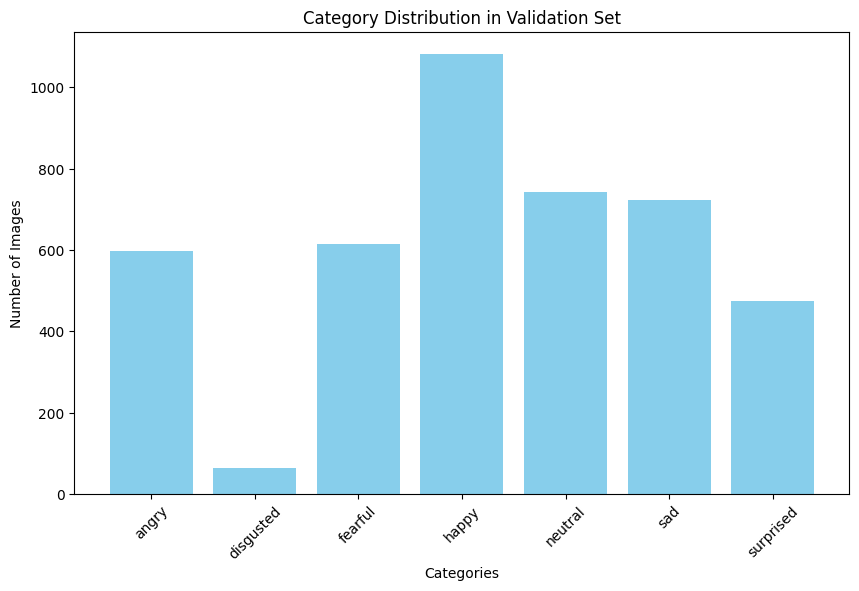

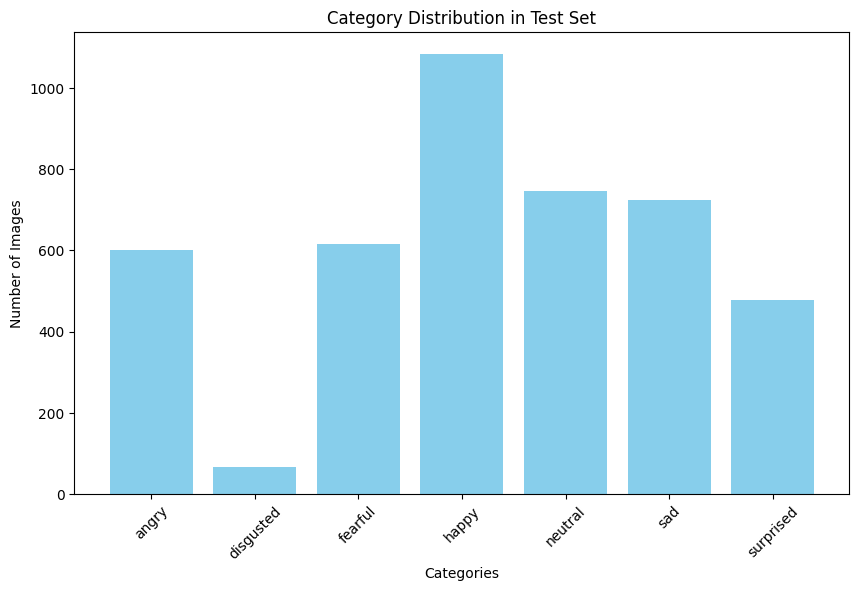

Sample Images from the 'angry' Category:


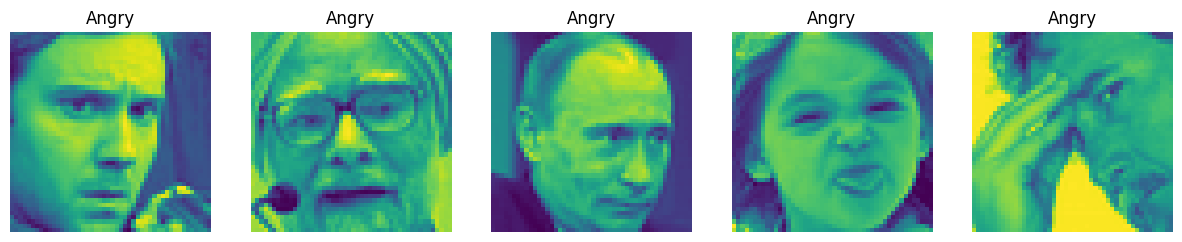

In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import os
from collections import Counter

# Define paths for subsets
train_dir = new_base_dir / "train"
validation_dir = new_base_dir / "validation"
test_dir = new_base_dir / "test"

# Count images in each category
def count_images(directory):
    counts = {}
    for category in os.listdir(directory):  # Assuming subfolders represent emotion categories
        category_path = directory / category
        counts[category] = len(os.listdir(category_path))
    return counts

# Display counts for each subset
print("Training set distribution:", count_images(train_dir))
print("Validation set distribution:", count_images(validation_dir))
print("Test set distribution:", count_images(test_dir))

# Visualize the distribution of categories in the training set
def plot_category_distribution(directory, title):
    counts = count_images(directory)
    categories = list(counts.keys())
    num_images = list(counts.values())
    
    plt.figure(figsize=(10, 6))
    plt.bar(categories, num_images, color="skyblue")
    plt.xlabel("Categories")
    plt.ylabel("Number of Images")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

plot_category_distribution(train_dir, "Category Distribution in Training Set")
plot_category_distribution(validation_dir, "Category Distribution in Validation Set")
plot_category_distribution(test_dir, "Category Distribution in Test Set")

# Plot sample images from a specific category in the training set
def plot_sample_images(directory, category, n=5):
    """
    Plots sample images for a specific category.
    Args:
        directory: Path to the image directory.
        category: Emotion category (e.g., 'angry', 'happy').
        n: Number of images to display.
    """
    category_path = directory / category
    img_filenames = os.listdir(category_path)[:n]
    
    fig, axes = plt.subplots(1, n, figsize=(15, 5))
    for i, ax in enumerate(axes):
        img_path = category_path / img_filenames[i]
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(category.capitalize())
    plt.show()

# Display sample images for a specific category
sample_category = "angry"  # Change to any category present in your dataset
print(f"Sample Images from the '{sample_category}' Category:")
plot_sample_images(train_dir, sample_category)


**Visualize Image Sizes:**

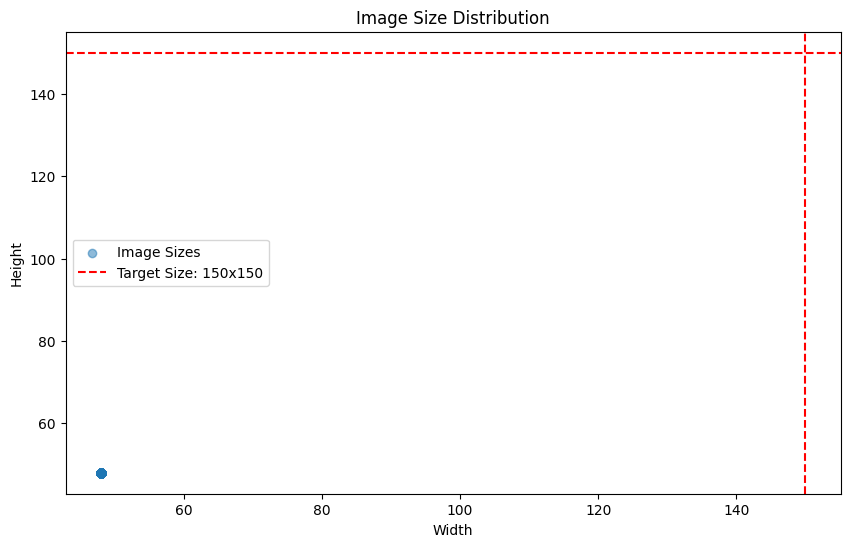

In [5]:
# Explore image sizes
image_sizes = []
for category in os.listdir(train_dir):  # Dynamically handle emotion categories
    for img_name in os.listdir(train_dir / category):
        img = Image.open(train_dir / category / img_name)
        image_sizes.append(img.size)

# Plot image size distribution
widths, heights = zip(*image_sizes)
plt.figure(figsize=(10, 6))
plt.scatter(widths, heights, alpha=0.5, label="Image Sizes")
plt.axhline(y=150, color="r", linestyle="--", label="Target Size: 150x150")
plt.axvline(x=150, color="r", linestyle="--")
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")
plt.legend()
plt.show()


**Class Distribution:**

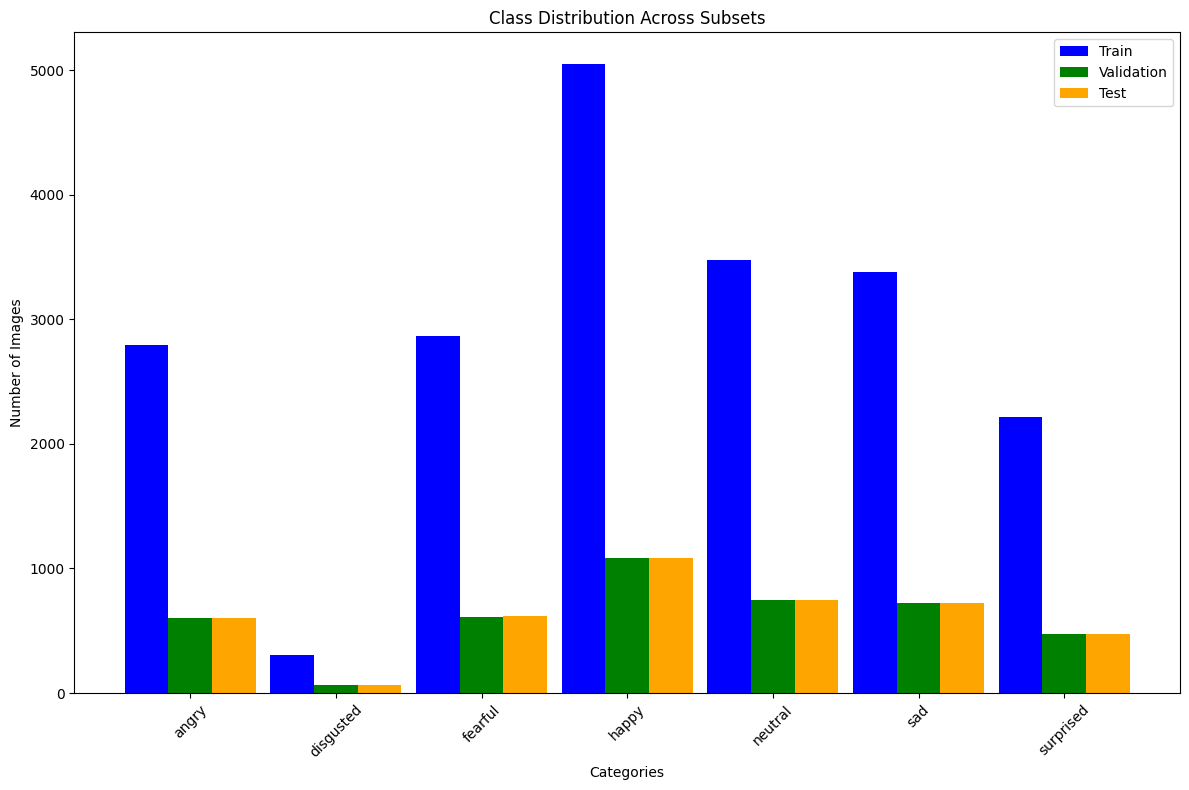

In [6]:
# Function to count images in each subset dynamically based on categories
def count_images_dynamic(directory):
    """
    Counts the number of images for each category in a given directory.
    Args:
        directory: Path to the directory (train/validation/test).
    Returns:
        A dictionary with counts for each category.
    """
    counts = {}
    for category in os.listdir(directory):
        counts[category] = len(os.listdir(directory / category))
    return counts

# Count images in each subset
train_counts = count_images_dynamic(train_dir)
validation_counts = count_images_dynamic(validation_dir)
test_counts = count_images_dynamic(test_dir)

# Prepare data for the bar chart
categories = list(train_counts.keys())  # Emotion categories
labels = ["Train", "Validation", "Test"]
train_values = [train_counts[category] for category in categories]
validation_values = [validation_counts[category] for category in categories]
test_values = [test_counts[category] for category in categories]

# Bar chart for class distribution
x = range(len(categories))  # Positions for categories
bar_width = 0.3

plt.figure(figsize=(12, 8))
plt.bar(x, train_values, width=bar_width, label="Train", color="blue")
plt.bar([i + bar_width for i in x], validation_values, width=bar_width, label="Validation", color="green")
plt.bar([i + 2 * bar_width for i in x], test_values, width=bar_width, label="Test", color="orange")
plt.xticks([i + bar_width for i in x], categories, rotation=45)
plt.xlabel("Categories")
plt.ylabel("Number of Images")
plt.title("Class Distribution Across Subsets")
plt.legend()
plt.tight_layout()
plt.show()


### 3. Train two networks (use callbacks to save the best model version):

**1. Define a Neural Network of your choice.**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Define paths
train_dir = str(new_base_dir / "train")
validation_dir = str(new_base_dir / "validation")
test_dir = str(new_base_dir / "test")

# Data generators
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255)
validation_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255)

# Update `class_mode` to "categorical" for multi-class classification
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=32, class_mode="categorical"
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir, target_size=(150, 150), batch_size=32, class_mode="categorical"
)

# Define the custom CNN for multi-class classification
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(512, activation="relu"),
    layers.Dense(train_generator.num_classes, activation="softmax")  # Multi-class output
])

# Compile the model with categorical crossentropy
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Callback to save the best model
custom_model_checkpoint = callbacks.ModelCheckpoint(
    "custom_emotion_model_best.keras", save_best_only=True, monitor="val_loss", mode="min"
)

# Train the model
history_custom = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=[custom_model_checkpoint]
)

# Save final model
model.save("custom_emotion_model_final.keras")


Found 20093 images belonging to 7 classes.
Found 4303 images belonging to 7 classes.


c:\Users\ektap\Documents\Conestoga\CSCN8010\CSCN8010_classical_ml\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20


c:\Users\ektap\Documents\Conestoga\CSCN8010\CSCN8010_classical_ml\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


628/628 ━━━━━━━━━━━━━━━━━━━━ 720s 1s/step - accuracy: 0.2806 - loss: 1.8151 - val_accuracy: 0.4346 - val_loss: 1.4871
Epoch 2/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 262s 417ms/step - accuracy: 0.4503 - loss: 1.4171 - val_accuracy: 0.4587 - val_loss: 1.4022
Epoch 3/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 348s 554ms/step - accuracy: 0.5590 - loss: 1.1596 - val_accuracy: 0.4985 - val_loss: 1.3443
Epoch 4/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 262s 417ms/step - accuracy: 0.6721 - loss: 0.8806 - val_accuracy: 0.5215 - val_loss: 1.4252
Epoch 5/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 245s 390ms/step - accuracy: 0.8268 - loss: 0.4953 - val_accuracy: 0.5062 - val_loss: 1.8202
Epoch 6/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 238s 380ms/step - accuracy: 0.9347 - loss: 0.2109 - val_accuracy: 0.5059 - val_loss: 2.6184
Epoch 7/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 205s 327ms/step - accuracy: 0.9747 - loss: 0.1000 - val_accuracy: 0.4876 - val_loss: 3.0283
Epoch 8/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 207s 329ms/step - accuracy: 0.9822 - loss: 0.0773 

**2. Fine-Tune VGG16 (pre-trained on imagenet). Make sure to use validation to test for over-fitting. Plot the appropriate graph.**

In [8]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, callbacks

# Load pre-trained VGG16
conv_base = VGG16(weights="imagenet", include_top=False, input_shape=(150, 150, 3))
conv_base.trainable = False  # Freeze the convolutional base

# Add a custom classifier on top
model_vgg16 = models.Sequential([
    conv_base,
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation="softmax")  # Multi-class output
])

# Compile the model for multi-class classification
model_vgg16.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Callback to save the best VGG16 model
vgg16_checkpoint = callbacks.ModelCheckpoint(
    "vgg16_emotion_best.keras", save_best_only=True, monitor="val_loss", mode="min"
)

# Train the VGG16 model
history_vgg16 = model_vgg16.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=[vgg16_checkpoint]
)

# Save final VGG16 model
model_vgg16.save("vgg16_emotion_final.keras")


Epoch 1/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 1326s 2s/step - accuracy: 0.3263 - loss: 1.7773 - val_accuracy: 0.4725 - val_loss: 1.4175
Epoch 2/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 1196s 2s/step - accuracy: 0.4161 - loss: 1.4969 - val_accuracy: 0.4924 - val_loss: 1.3784
Epoch 3/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 1215s 2s/step - accuracy: 0.4272 - loss: 1.4554 - val_accuracy: 0.4973 - val_loss: 1.3586
Epoch 4/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 1147s 2s/step - accuracy: 0.4489 - loss: 1.4038 - val_accuracy: 0.5027 - val_loss: 1.3264
Epoch 5/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 1664s 3s/step - accuracy: 0.4678 - loss: 1.3718 - val_accuracy: 0.5210 - val_loss: 1.2894
Epoch 6/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 2242s 4s/step - accuracy: 0.4669 - loss: 1.3596 - val_accuracy: 0.5152 - val_loss: 1.2935
Epoch 7/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 1928s 3s/step - accuracy: 0.4787 - loss: 1.3428 - val_accuracy: 0.5252 - val_loss: 1.2772
Epoch 8/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 1402s 2s/step - accuracy: 0.4861 - loss: 1.3101 - 

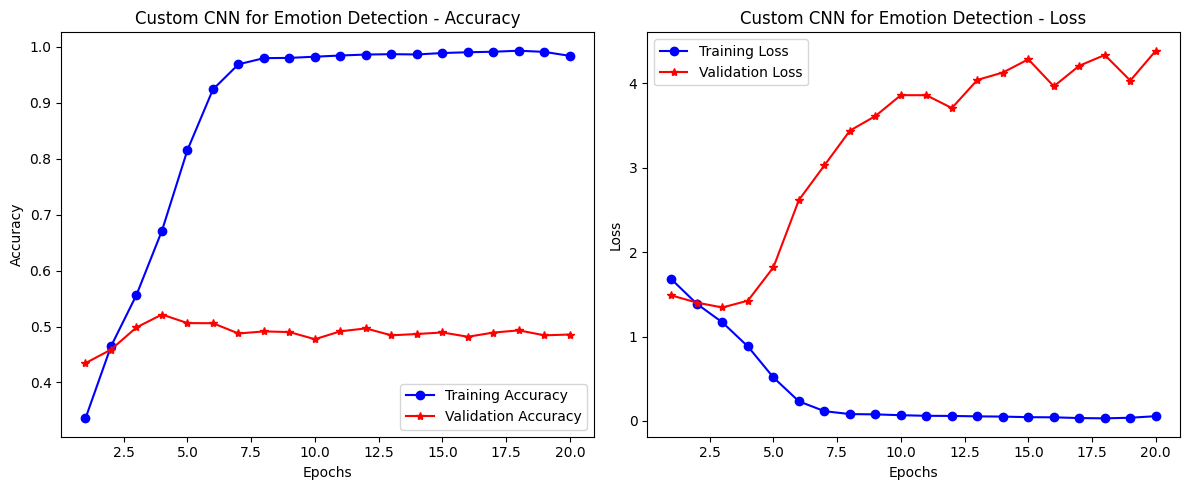

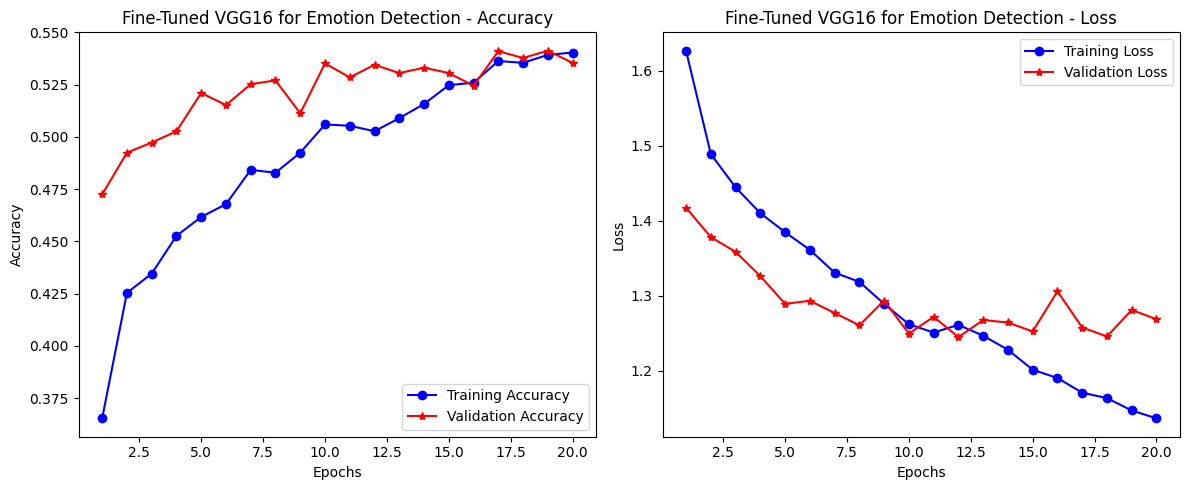

In [9]:
import matplotlib.pyplot as plt

# Function to plot training history
def plot_training_history(history, title):
    """
    Plots accuracy and loss curves for training and validation.
    
    Args:
        history: The history object returned from model.fit().
        title: A string to display as the title of the plots.
    """
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    
    epochs = range(1, len(acc) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, "bo-", label="Training Accuracy")
    plt.plot(epochs, val_acc, "r*-", label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    
    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, "bo-", label="Training Loss")
    plt.plot(epochs, val_loss, "r*-", label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Plot for your Custom CNN
plot_training_history(history_custom, "Custom CNN for Emotion Detection")

# Plot for Fine-Tuned VGG16
plot_training_history(history_vgg16, "Fine-Tuned VGG16 for Emotion Detection")


### 4. Explore the relative performance of the models (make sure to load the best version of each model):  

1. accuracy

2. confusion metric

3. precision, recall, F1-score,
    
4. precision-recall curve.

5. Explore specific examples in which the model failed to predict correctly.


In [18]:
from tensorflow.keras.models import load_model

# Load the best models
custom_emotion_model_best = load_model("custom_emotion_model_best.keras")
vgg16_emotion_model_best = load_model("vgg16_emotion_best.keras")

In [41]:
# Test data generator for your dataset
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255)

# Create test data generator
test_generator = test_datagen.flow_from_directory(
    test_dir, 
    target_size=(150, 150),  # Resize images to 150x150 (you can adjust this if needed)
    batch_size=32,           # Batch size for evaluation
    class_mode="binary",     # Since it's a binary classification task
    shuffle=False            # Keep shuffle=False so we can track the true labels
)

# Print the details of the generated test data
print(f"Test generator details: {test_generator}")


Found 4313 images belonging to 7 classes.
Test generator details: <keras.src.legacy.preprocessing.image.DirectoryIterator object at 0x000001B43A879220>


135/135 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step
Shape of predictions before flattening: (4313, 7)
Number of samples in test_generator: 4313
Shape of predictions array after processing: (4313,)
Length of true labels array: 4313
--- Custom CNN ---
Accuracy: 0.48
Confusion Matrix:
[[201   0  71  78 113 110  27]
 [ 21   7   7   3   7  16   5]
 [ 68   0 197  59  87 120  85]
 [ 49   0  57 721 130 100  26]
 [ 55   0  67  87 382 132  23]
 [ 88   0  87  98 174 265  13]
 [ 12   0  59  33  34  33 306]]
Classification Report:
              precision    recall  f1-score   support

     Class 1       0.41      0.34      0.37       600
     Class 2       1.00      0.11      0.19        66
     Class 3       0.36      0.32      0.34       616
     Class 4       0.67      0.67      0.67      1083
     Class 5       0.41      0.51      0.46       746
     Class 6       0.34      0.37      0.35       725
     Class 7       0.63      0.64      0.64       477

    accuracy                           0.48      431

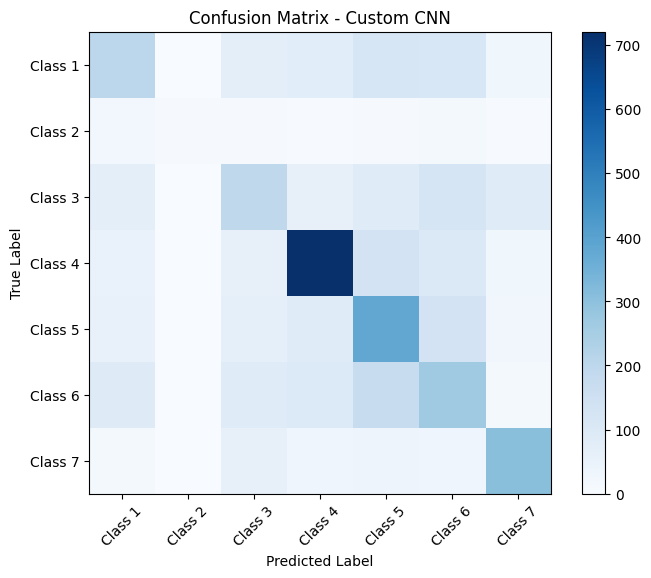

135/135 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step
Shape of predictions before flattening: (4313, 7)
Number of samples in test_generator: 4313
Shape of predictions array after processing: (4313,)
Length of true labels array: 4313
--- VGG16 ---
Accuracy: 0.52
Confusion Matrix:
[[231   0  17  78 122 140  12]
 [ 23   0   0   7   8  26   2]
 [ 80   0 111  58 110 187  70]
 [ 42   0   5 861  95  68  12]
 [ 29   0  24 109 421 146  17]
 [ 83   0  19  96 173 346   8]
 [ 29   0  38  41  71  14 284]]
Classification Report:
              precision    recall  f1-score   support

     Class 1       0.45      0.39      0.41       600
     Class 2       0.00      0.00      0.00        66
     Class 3       0.52      0.18      0.27       616
     Class 4       0.69      0.80      0.74      1083
     Class 5       0.42      0.56      0.48       746
     Class 6       0.37      0.48      0.42       725
     Class 7       0.70      0.60      0.64       477

    accuracy                           0.52      4313
   

c:\Users\ektap\Documents\Conestoga\CSCN8010\CSCN8010_classical_ml\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ektap\Documents\Conestoga\CSCN8010\CSCN8010_classical_ml\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ektap\Documents\Conestoga\CSCN8010\CSCN8010_classical_ml\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 

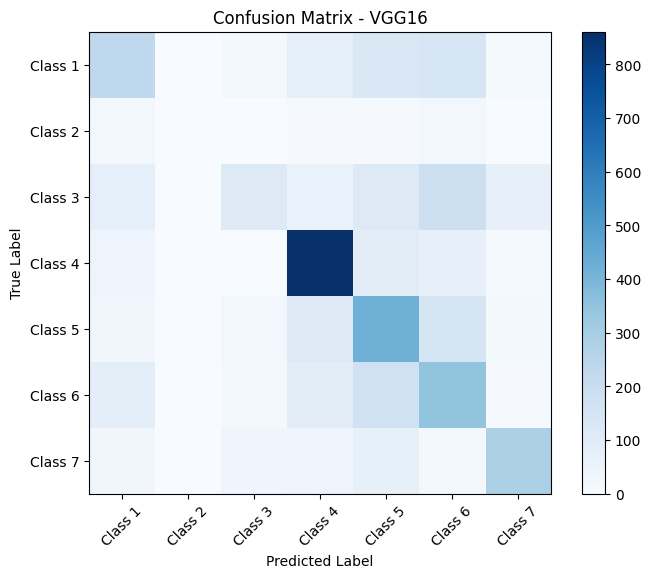

In [47]:
def evaluate_model(model, test_generator, name, batch_size=32):
    # Set batch size and calculate steps
    test_generator.batch_size = batch_size
    steps = int(np.ceil(test_generator.samples / test_generator.batch_size))
    
    # Get predictions
    predictions = model.predict(test_generator, steps=steps, verbose=1)
    
    # Check shape of predictions
    print(f"Shape of predictions before flattening: {predictions.shape}")
    
    # For multi-class, take the class with the highest probability
    predictions_binary = np.argmax(predictions, axis=1)
    
    # Get true labels
    true_labels = test_generator.classes
    
    # Debugging logs
    print(f"Number of samples in test_generator: {test_generator.samples}")
    print(f"Shape of predictions array after processing: {predictions_binary.shape}")
    print(f"Length of true labels array: {len(true_labels)}")
    
    # Validate alignment between predictions and true labels
    if len(predictions_binary) != len(true_labels):
        raise ValueError(f"Mismatch between predictions ({len(predictions_binary)}) and true labels ({len(true_labels)})")
    
    # Calculate metrics
    accuracy = np.mean(predictions_binary == true_labels)
    conf_matrix = confusion_matrix(true_labels, predictions_binary)
    
    # Update target names to reflect the correct number of classes (7 in this case)
    target_names = [f"Class {i}" for i in range(1, 8)]  # Assuming 7 classes, change if needed
    report = classification_report(true_labels, predictions_binary, target_names=target_names)
    
    # Display results
    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Confusion Matrix:\n{conf_matrix}")
    print(f"Classification Report:\n{report}")
    
    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {name}")
    plt.colorbar()
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(np.arange(7), target_names, rotation=45)
    plt.yticks(np.arange(7), target_names)
    plt.show()
    
    return predictions_binary, true_labels

# Example usage with a smaller batch size
custom_preds, custom_labels = evaluate_model(custom_model_best, test_generator, "Custom CNN", batch_size=32)
vgg16_preds, vgg16_labels = evaluate_model(vgg16_model_best, test_generator, "VGG16", batch_size=32)


2234 misclassified examples found.


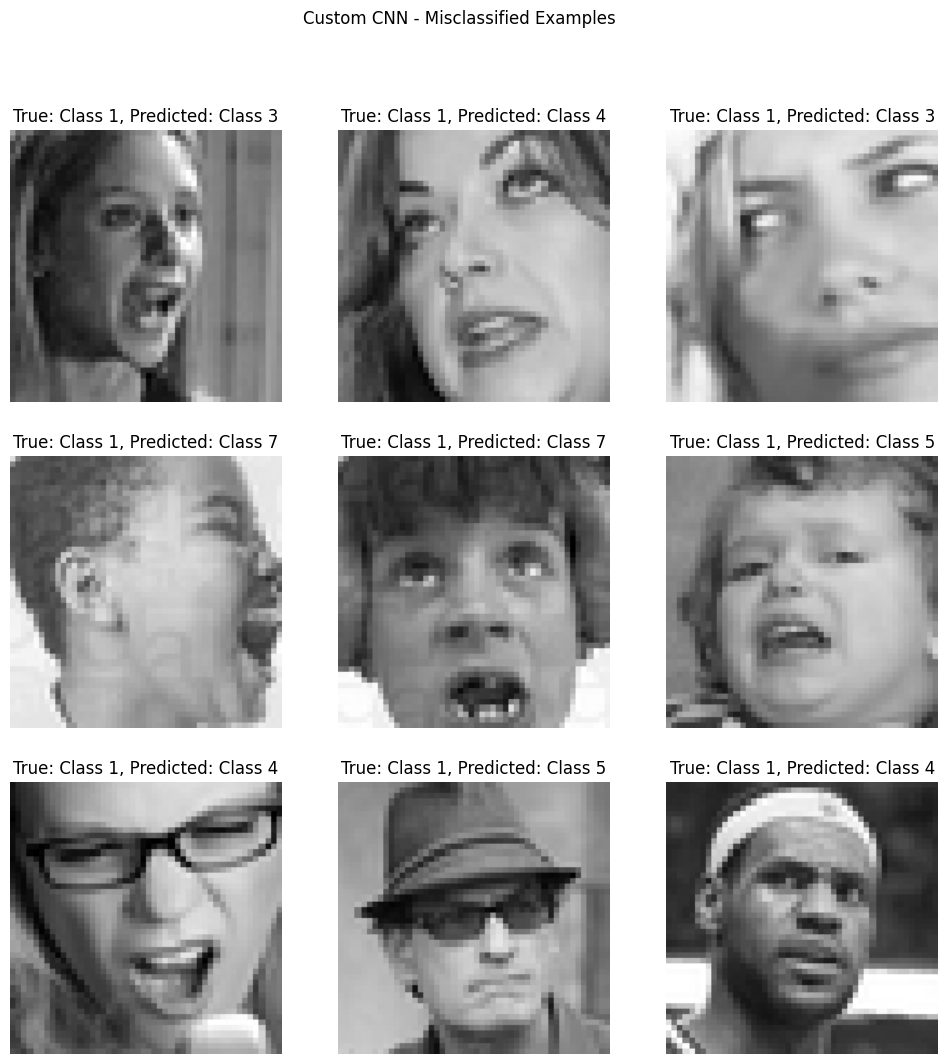

2059 misclassified examples found.


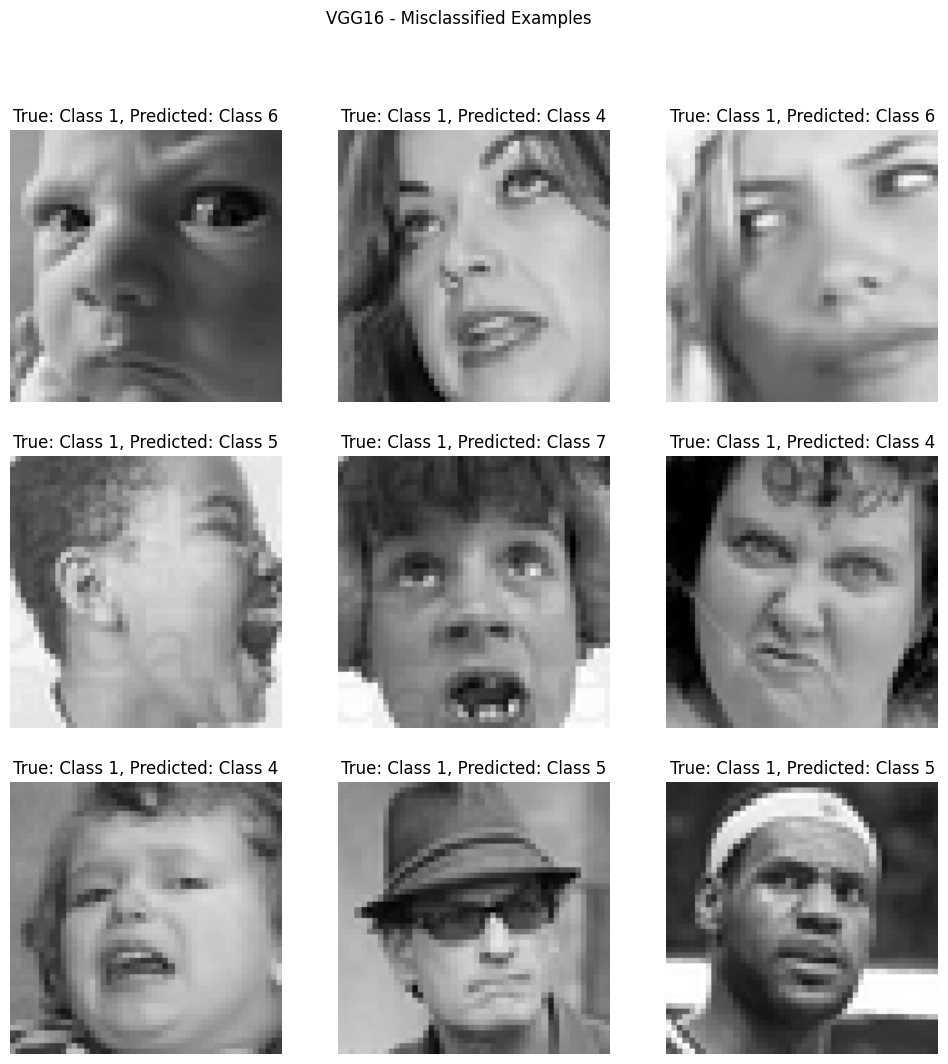

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Function to display misclassified examples for your dataset
def show_misclassified(predictions, true_labels, generator, title, class_names=None):
    # Misclassified examples
    misclassified_indices = np.where(predictions != true_labels)[0]
    print(f"{len(misclassified_indices)} misclassified examples found.")
    
    if len(misclassified_indices) > 0:
        plt.figure(figsize=(12, 12))
        
        # Show up to 9 misclassified examples
        for i, idx in enumerate(misclassified_indices[:9]):
            img_path = generator.filepaths[idx]
            img = tf.keras.utils.load_img(img_path, target_size=(150, 150))
            plt.subplot(3, 3, i + 1)
            
            # For multi-class, display the predicted and true class names
            true_class = true_labels[idx]
            predicted_class = predictions[idx]
            
            # If multi-class, we need to map indices to class names
            if class_names:
                true_label_name = class_names[true_class]
                predicted_label_name = class_names[predicted_class]
            else:
                true_label_name = 'Class {}'.format(true_class + 1)  # Default naming, adjust if necessary
                predicted_label_name = 'Class {}'.format(predicted_class + 1)  # Default naming, adjust if necessary

            plt.imshow(img)
            plt.title(f"True: {true_label_name}, Predicted: {predicted_label_name}")
            plt.axis("off")
        
        plt.suptitle(title)
        plt.show()

# Example class names for multi-class classification (adjust based on your dataset)
# For example, if you have 7 classes:
class_names = [f"Class {i}" for i in range(1, 8)]  # Change this list to your actual class names

# Show misclassified examples for Custom CNN
show_misclassified(custom_preds, custom_labels, test_generator, "Custom CNN - Misclassified Examples", class_names)

# Show misclassified examples for VGG16
show_misclassified(vgg16_preds, vgg16_labels, test_generator, "VGG16 - Misclassified Examples", class_names)
